In [1]:
import json
import random

from collections import defaultdict
from pathlib import Path

import boto3
import matplotlib.pyplot as plt

from PIL import Image
from matplotlib.patches import Rectangle

In [2]:
# =========================================================
# CONFIG
# =========================================================

ENDPOINT_NAME = "parking-endpoint"

S3_BUCKET = "mlops-parking-spots"

S3_IMAGES_PREFIX = "data/test"

runtime = boto3.client("sagemaker-runtime")
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"

In [3]:
# =========================================================
# GET BOXES FROM LOCAL COCO
# =========================================================

def test_image_boxes(
    split_dir=DATA_DIR / "test",
    image_to_predict=None,
    seed=None
):

    coco = read_coco(split_dir)

    annotations_by_image_id = defaultdict(list)

    for ann in coco["annotations"]:

        bbox = ann.get("bbox")

        if (
            bbox
            and len(bbox) == 4
            and bbox[2] > 0
            and bbox[3] > 0
        ):
            annotations_by_image_id[
                ann["image_id"]
            ].append(ann)

    if image_to_predict is None:

        candidate_images = [
            img
            for img in coco["images"]
            if annotations_by_image_id.get(img["id"])
        ]

        if not candidate_images:
            raise ValueError(
                f"No test images found in {split_dir}"
            )

        rng = random.Random(seed) if seed else random

        image_record = rng.choice(candidate_images)

    else:

        requested_name = Path(image_to_predict).name

        matches = [
            img
            for img in coco["images"]
            if img["file_name"] == requested_name
        ]

        if not matches:
            raise ValueError(
                f"Image not found: {requested_name}"
            )

        image_record = matches[0]

    image_path = split_dir / image_record["file_name"]

    box_annotations = [
        {"bbox": ann["bbox"]}
        for ann in annotations_by_image_id[
            image_record["id"]
        ]
    ]

    return image_path, box_annotations

def read_coco(split_dir: Path) -> dict:
    annotations_path = split_dir / "_annotations.coco.json"
    if not annotations_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {annotations_path}")
    with annotations_path.open("r", encoding="utf-8") as f:
        return json.load(f)


In [4]:
# =========================================================
# CALL ENDPOINT
# =========================================================

def predict_parking_boxes_endpoint(
    image_name,
    box_annotations
):

    boxes = [
        ann["bbox"]
        for ann in box_annotations
    ]

    image_s3_uri = (
        f"s3://{S3_BUCKET}/"
        f"{S3_IMAGES_PREFIX}/"
        f"{image_name}"
    )

    payload = {
        "image_s3_uri": image_s3_uri,
        "boxes": boxes
    }

    response = runtime.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="application/json",
        Body=json.dumps(payload)
    )

    result = response["Body"].read()

    return json.loads(result)

In [5]:
# =========================================================
# DISPLAY
# =========================================================

def display_prediction_boxes(
    image_path,
    predictions
):

    image = Image.open(image_path).convert("RGB")

    fig, ax = plt.subplots(figsize=(10, 10))

    ax.imshow(image)

    ax.set_title(Path(image_path).name)

    ax.axis("off")

    for result in predictions:

        x, y, w, h = result["bbox_xywh"]

        label = result["predicted_label"]

        color = (
            "lime"
            if label == "space-empty"
            else "red"
        )

        short_label = (
            "Empty"
            if label == "space-empty"
            else "Occupied"
        )

        ax.add_patch(
            Rectangle(
                (x, y),
                w,
                h,
                fill=False,
                edgecolor=color,
                linewidth=1.5
            )
        )

        ax.text(
            x,
            max(0, y - 3),
            short_label,
            color="white",
            fontsize=6,
            bbox={
                "facecolor": color,
                "alpha": 0.75,
                "pad": 1,
                "edgecolor": "none",
            },
        )

    plt.show()


image: 2013-04-15_18_00_13_jpg.rf.a81662bde9d55256a28a145c46770be3.jpg
boxes tested: 40
empty spaces: 13
occupied spaces: 27


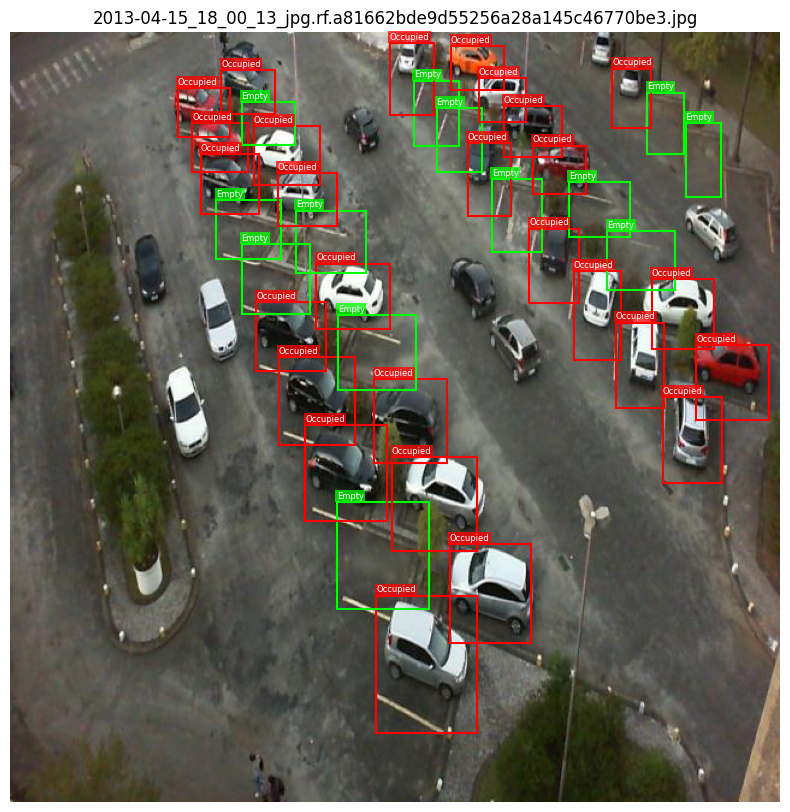

In [15]:
# =========================================================
# MAIN
# =========================================================

TEST_IMAGE_NAME = "2013-04-15_18_00_13_jpg.rf.a81662bde9d55256a28a145c46770be3.jpg"

test_image_path, test_box_annotations = test_image_boxes(
    image_to_predict=TEST_IMAGE_NAME
)

predictions = predict_parking_boxes_endpoint(
    TEST_IMAGE_NAME,
    test_box_annotations
)

empty_spaces = sum(
    p["predicted_label"] == "space-empty"
    for p in predictions
)

occupied_spaces = sum(
    p["predicted_label"] == "space-occupied"
    for p in predictions
)

print(f"image: {TEST_IMAGE_NAME}")

print(f"boxes tested: {len(test_box_annotations)}")

print(f"empty spaces: {empty_spaces}")

print(f"occupied spaces: {occupied_spaces}")

display_prediction_boxes(
    test_image_path,
    predictions
)

In [ ]:
import json

from inference import (
    model_fn,
    input_fn,
    predict_fn,
    output_fn
)

# =====================================================
# LOAD MODEL
# =====================================================

model_data = model_fn(".")

print("MODEL LOADED")

# =====================================================
# CREATE TEST PAYLOAD
# =====================================================

TEST_IMAGE_NAME = "2012-09-11_15_53_00_jpg.rf.8282544a640a23df05bd245a9210e663.jpg"

test_image_path, test_box_annotations = test_image_boxes(
    image_to_predict=TEST_IMAGE_NAME
)

boxes = [
        ann["bbox"]
        for ann in test_box_annotations
    ]

image_s3_uri = (
        f"s3://{S3_BUCKET}/"
        f"{S3_IMAGES_PREFIX}/"
        f"{TEST_IMAGE_NAME}"
    )

payload = {
        "image_s3_uri": image_s3_uri,
        "boxes": boxes
    }

request_body = json.dumps(payload)

# =====================================================
# INPUT_FN
# =====================================================

parsed_input = input_fn(
    request_body,
    "application/json"
)

print("INPUT PARSED")

# =====================================================
# PREDICT_FN
# =====================================================

prediction = predict_fn(
    parsed_input,
    model_data
)

print("PREDICTION SUCCESS")

# =====================================================
# OUTPUT_FN
# =====================================================

response_body, response_content_type = output_fn(
    prediction,
    "application/json"
)

print("OUTPUT SUCCESS")

print(response_body)